In [1]:
import os
import pandas as pd
import numpy as np
import time

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

import traceback
import psutil as ps
import warnings
warnings.filterwarnings("ignore")

In [2]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates = ["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
0,2020-06-14,5337.8,10959,4.3,5565.7,2699.1,165697.5,167937.3,98,3793.325000,...,9607.307254,9734.764259,166,0.280231,-0.959933,6,14,6,2,1
1,2020-06-21,4730.3,14232,147.7,5005.0,2823.0,165469.8,167733.8,98,3920.600000,...,938.525879,998.828316,173,0.162807,-0.986658,6,21,6,2,1
2,2020-06-28,4805.3,14218,134.0,4860.0,2805.0,165739.1,168004.0,98,4026.725000,...,953.799090,1011.551314,180,0.043022,-0.999074,6,28,6,2,1
3,2020-07-05,4836.4,14226,71.5,5019.4,2418.9,165574.1,167835.1,98,4125.587500,...,984.037592,1039.815056,187,-0.077386,-0.997001,6,5,7,3,1
4,2020-07-12,4825.6,14355,119.3,4882.1,2816.8,165505.7,167765.9,98,4234.545833,...,989.299329,1041.021251,194,-0.196673,-0.980469,6,12,7,3,1


In [3]:
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
0,2020-06-14,5337.8,10959,4.3,5565.7,2699.1,165697.5,167937.3,98,3793.325000,...,9607.307254,9734.764259,166,0.280231,-0.959933,6,14,6,2,1
1,2020-06-21,4730.3,14232,147.7,5005.0,2823.0,165469.8,167733.8,98,3920.600000,...,938.525879,998.828316,173,0.162807,-0.986658,6,21,6,2,1
2,2020-06-28,4805.3,14218,134.0,4860.0,2805.0,165739.1,168004.0,98,4026.725000,...,953.799090,1011.551314,180,0.043022,-0.999074,6,28,6,2,1
3,2020-07-05,4836.4,14226,71.5,5019.4,2418.9,165574.1,167835.1,98,4125.587500,...,984.037592,1039.815056,187,-0.077386,-0.997001,6,5,7,3,1
4,2020-07-12,4825.6,14355,119.3,4882.1,2816.8,165505.7,167765.9,98,4234.545833,...,989.299329,1041.021251,194,-0.196673,-0.980469,6,12,7,3,1


In [4]:
weather_data.set_index("Date",inplace = True)

In [5]:
weather_data["Temperature_seasonal_diff"] = (
    weather_data["Temperature"] - weather_data["Temperature"].shift(24)
)

In [6]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 291 entries, 2020-06-14 to 2026-01-04
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        291 non-null    float64
 1   Relative_humidity                  291 non-null    int64  
 2   Rain                               291 non-null    float64
 3   Soil_temperature                   291 non-null    float64
 4   Wind_speed                         291 non-null    float64
 5   Surface_pressure                   291 non-null    float64
 6   Pressure_msl                       291 non-null    float64
 7   is_day                             291 non-null    int64  
 8   Rolling Mean of Temperature        291 non-null    float64
 9   Rolling Mean of Relative_humidity  291 non-null    float64
 10  Rolling Mean of Rain               291 non-null    float64
 11  Rolling Mean of Soil_temperature   291 

In [7]:
monthly_temp = weather_data["Temperature"].resample('W').sum()

In [8]:
#monthly_temp = monthly_temp - monthly_temp.shift(12)

In [9]:
#temp_diff = weather_data["Temperature"].diff(24).diff().dropna()

In [6]:
monthly_diff = weather_data["Temperature"] - weather_data["Temperature"].shift(4)

In [11]:
weather_data["temp_log"] = np.log1p(weather_data["Temperature"])

In [12]:
weather_data["temp_sqrt"] = np.sqrt(weather_data["Temperature"])

In [13]:
from scipy.stats import boxcox

weather_data["temp_boxcox"], lam = boxcox(weather_data["Temperature"])

In [14]:
weekly_data = np.log1p(monthly_temp)

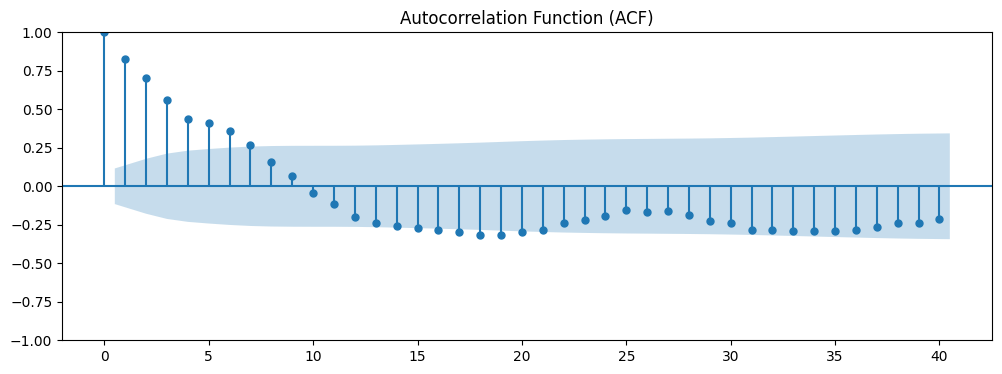

In [9]:
fig_acf = plot_acf(monthly_diff.dropna(), lags = 40, title = "Autocorrelation Function (ACF)")
fig_acf.set_size_inches(12,4)
plt.show()

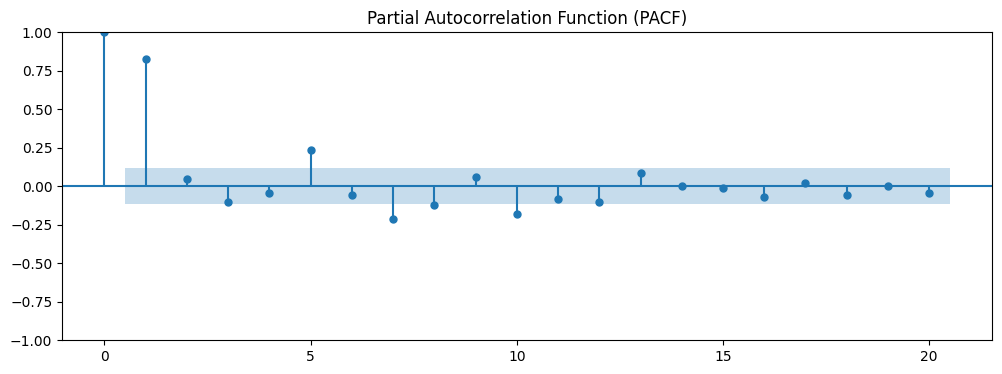

In [8]:
fig_pacf = plot_pacf(monthly_diff.dropna(), lags=20, title='Partial Autocorrelation Function (PACF)')
fig_pacf.set_size_inches(12,4)
plt.show()

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [18]:
sarima_model = SARIMAX(weekly_data, 
                       order=(1, 0, 1),           # Non-seasonal parameters
                       seasonal_order=(1, 1, 1, 4),  # Seasonal parameters (P, D, Q, m)
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

In [19]:
sarima_fit = sarima_model.fit(disp=False)

In [20]:
sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                       Temperature   No. Observations:                  291
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 4)   Log Likelihood                 234.383
Date:                           Fri, 10 Jul 2026   AIC                           -458.767
Time:                                   19:01:35   BIC                           -440.575
Sample:                               06-14-2020   HQIC                          -451.471
                                    - 01-04-2026                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9674      0.030     32.407      0.000       0.909       1.026
ma.L1         -0.0077      0.082     -0.094      0.925      -0.168       0.153
ar.S.L4        0.3254      0.079      4.135      0.000       0.171       0.480
ma.S.L4       -0.9627      0.063    -15.361      0.000      -1.085      -0.840
sigma2         0.0107      0.000     33.486      0.000       0.010       0.011
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              8606.14
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.96   Skew:                            -2.54
Prob(H) (two-sided):                  0.00   Kurtosis:                        29.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

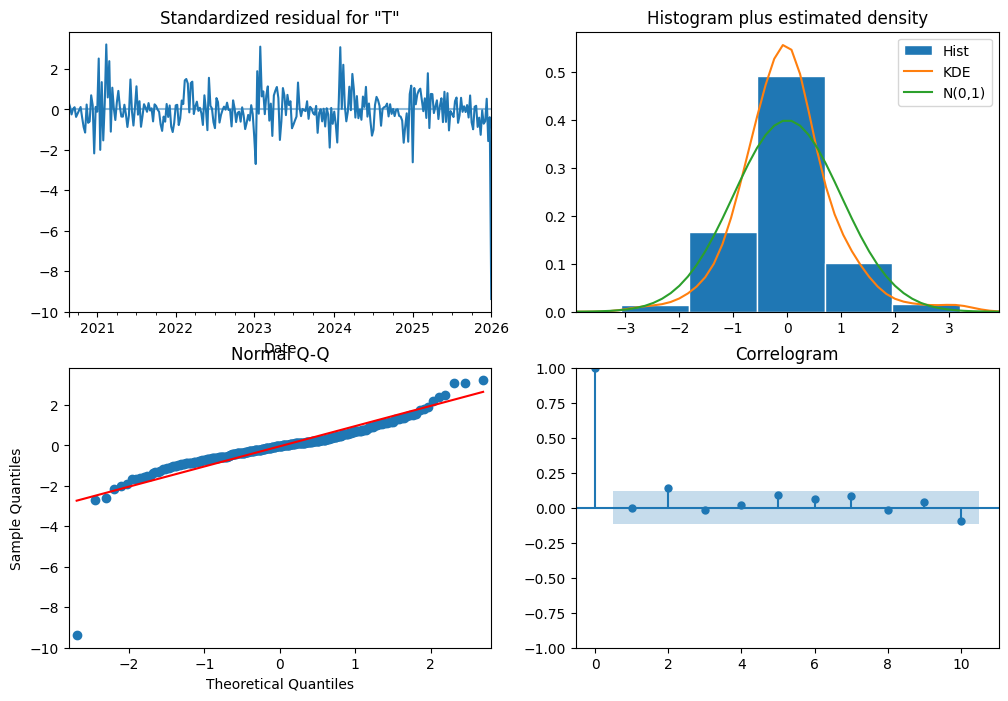

In [21]:
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
train_data = monthly_temp[:int(0.9*len(monthly_temp))]
test_data = monthly_temp[int(0.9*len(monthly_temp)):]

In [24]:
forecast = sarima_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [25]:
# Evaluate model performance
mae = mean_absolute_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
mape = np.mean(np.abs((test_data - forecast_mean) / test_data)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 4141.04
Root Mean Squared Error (RMSE): 4283.31
Mean Absolute Percentage Error (MAPE): nan%


In [26]:
from statsmodels.tsa.arima.model import ARIMA

In [27]:
model = ARIMA(monthly_temp, order=(3, 0, 2))  # p=1, d=0, q=2
model_fit = model.fit()

In [28]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Temperature   No. Observations:                  291
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -2094.785
Date:                Fri, 10 Jul 2026   AIC                           4203.570
Time:                        19:01:37   BIC                           4229.283
Sample:                    06-14-2020   HQIC                          4213.871
                         - 01-04-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4199.7587    503.295      8.345      0.000    3213.319    5186.199
ar.L1         -0.4325      0.065     -6.607      0.000      -0.561      -0.304
ar.L2          0.4972      0.045     11.122      0.000       0.410       0.585
ar.L3          0.8121      0.065     12.550      0.000       0.685       0.939
ma.L1          1.4607      0.033     43.625      0.000       1.395       1.526
ma.L2          0.9566      0.036     26.759      0.000       0.887       1.027
sigma2      1.034e+05   7984.632     12.951      0.000    8.78e+04    1.19e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                19.06
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.27   Skew:                            -0.30
Prob(H) (two-sided):                  0.25   Kurtosis:                         4.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

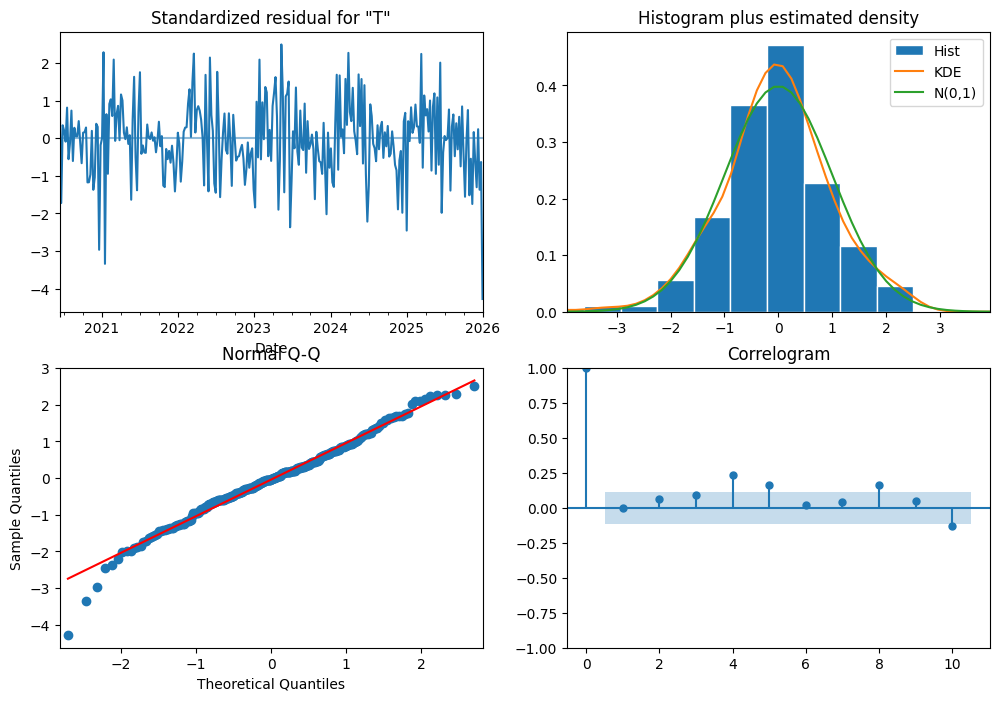

In [29]:
model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [30]:
forecast = model_fit.get_forecast(steps=len(test_data))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [1]:
# Evaluate model performance
mae = mean_absolute_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
mape = np.mean(np.abs((test_data - forecast_mean) / test_data)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

NameError: name 'mean_absolute_error' is not defined

In [32]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/train_arima_model.py"

In [33]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.models.train_arima_model import training

In [34]:
obj = training(data = monthly_temp,non_seasonal_perameters = (2,0,2), seasonal_perameters = (1, 1, 1, 12))

TypeError: training() takes no arguments

In [ ]:
type(training)

In [ ]:
import inspect

print(inspect.signature(training))